# 01 — Data Exploration

This notebook collects live market data via the Binance public API and explores the raw signals used by the risk scoring pipeline.

**Pipeline position:** Raw API → **EDA** → Feature Engineering → Model Training

Symbols: `BTCUSDT`, `ETHUSDT`, `BNBUSDT`, `SOLUSDT`, `XRPUSDT`  
Granularity: 1-hour klines, 500 bars (~21 days)

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from src.ingestion.collector import DataCollector

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
COLORS = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800']
SYMBOLS = ['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'SOLUSDT', 'XRPUSDT']

## 1. Collect Live Market Data

In [2]:
# Jupyter runs its own event loop — use await directly instead of asyncio.run()
async with DataCollector() as c:
    snapshots = await c.collect_all(SYMBOLS)

df_klines = DataCollector.snapshots_to_kline_df(snapshots)
df_ticker = DataCollector.snapshots_to_ticker_df(snapshots)

print(f'Collected {len(snapshots)} symbols, {len(df_klines)} kline rows')
df_klines.head(3)

2026-04-26 16:15:19 [info     ] collect_all_start              symbols=['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'SOLUSDT', 'XRPUSDT']
2026-04-26 16:15:19 [info     ] collecting                     symbol=BTCUSDT
2026-04-26 16:15:19 [info     ] collecting                     symbol=ETHUSDT
2026-04-26 16:15:19 [info     ] collecting                     symbol=BNBUSDT
2026-04-26 16:15:19 [info     ] collecting                     symbol=SOLUSDT
2026-04-26 16:15:19 [info     ] collecting                     symbol=XRPUSDT
2026-04-26 16:15:19 [debug    ] binance_spot_request           elapsed=0.22879537497647107 params={'symbol': 'BTCUSDT', 'limit': 20} path=/api/v3/depth
2026-04-26 16:15:19 [debug    ] binance_spot_request           elapsed=0.23086187499575317 params={'symbol': 'ETHUSDT'} path=/api/v3/ticker/24hr
2026-04-26 16:15:19 [debug    ] binance_spot_request           elapsed=0.23240212502423674 params={'symbol': 'BNBUSDT', 'limit': 20} path=/api/v3/depth
2026-04-26 16:15:19 [debug    ] bi

,symbol,open_time,close_time,open,high,low,close,volume,quote_volume,num_trades,taker_buy_base_volume,taker_buy_quote_volume
0,BNBUSDT,2026-04-05 12:00:00,2026-04-05 12:59:59.999,593.97,593.98,589.05,589.58,5189.572,3.069571e+06,27707,2432.828,1.439134e+06
1,BNBUSDT,2026-04-05 13:00:00,2026-04-05 13:59:59.999,589.57,589.64,587.13,589.10,4954.615,2.916102e+06,27619,2042.186,1.202051e+06
2,BNBUSDT,2026-04-05 14:00:00,2026-04-05 14:59:59.999,589.09,590.95,588.88,589.50,3064.530,1.807677e+06,19652,1361.478,8.031508e+05


## 2. Price History — Normalized Returns

Normalize to 100 at the start to compare relative performance across assets.

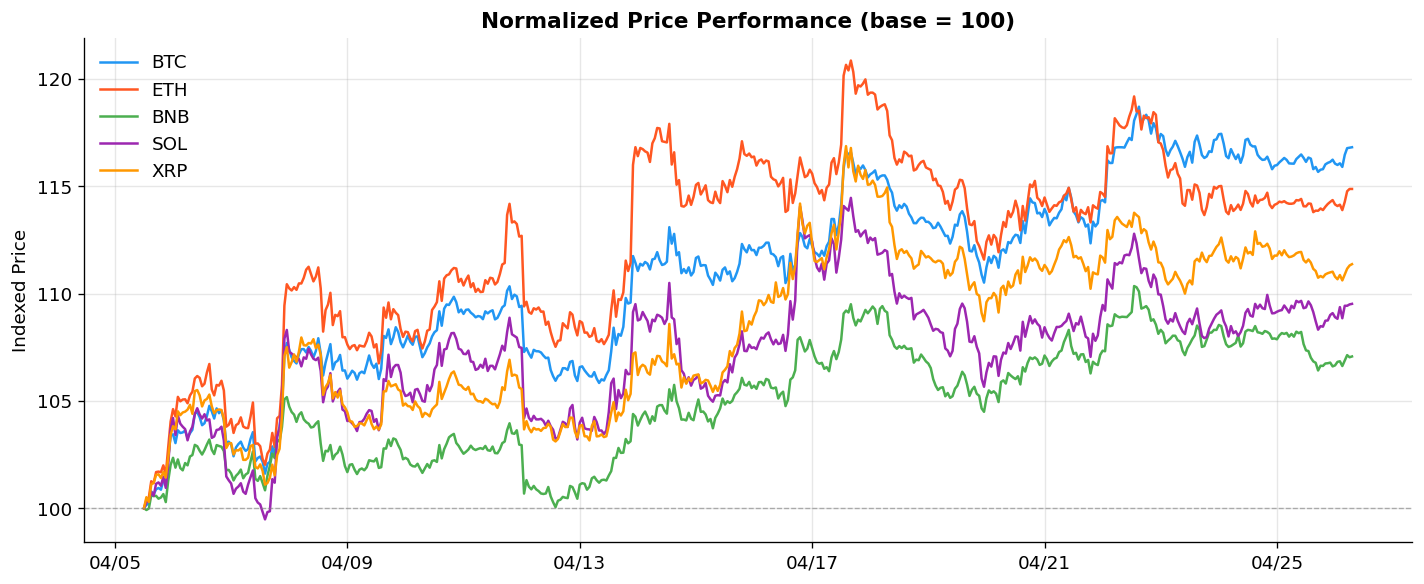

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))

for sym, color in zip(SYMBOLS, COLORS):
    sub = df_klines[df_klines['symbol'] == sym].sort_values('open_time')
    normalized = sub['close'] / sub['close'].iloc[0] * 100
    ax.plot(sub['open_time'], normalized, label=sym.replace('USDT', ''), color=color, linewidth=1.5)

ax.axhline(100, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_title('Normalized Price Performance (base = 100)', fontsize=13, fontweight='bold')
ax.set_ylabel('Indexed Price')
ax.legend(frameon=False)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
plt.tight_layout()
plt.show()

## 3. Log Return Distribution

Log returns are the primary input to volatility features. We check:
- Distributional shape (fat tails expected in crypto)
- Excess kurtosis (kurtosis > 3 = leptokurtic)

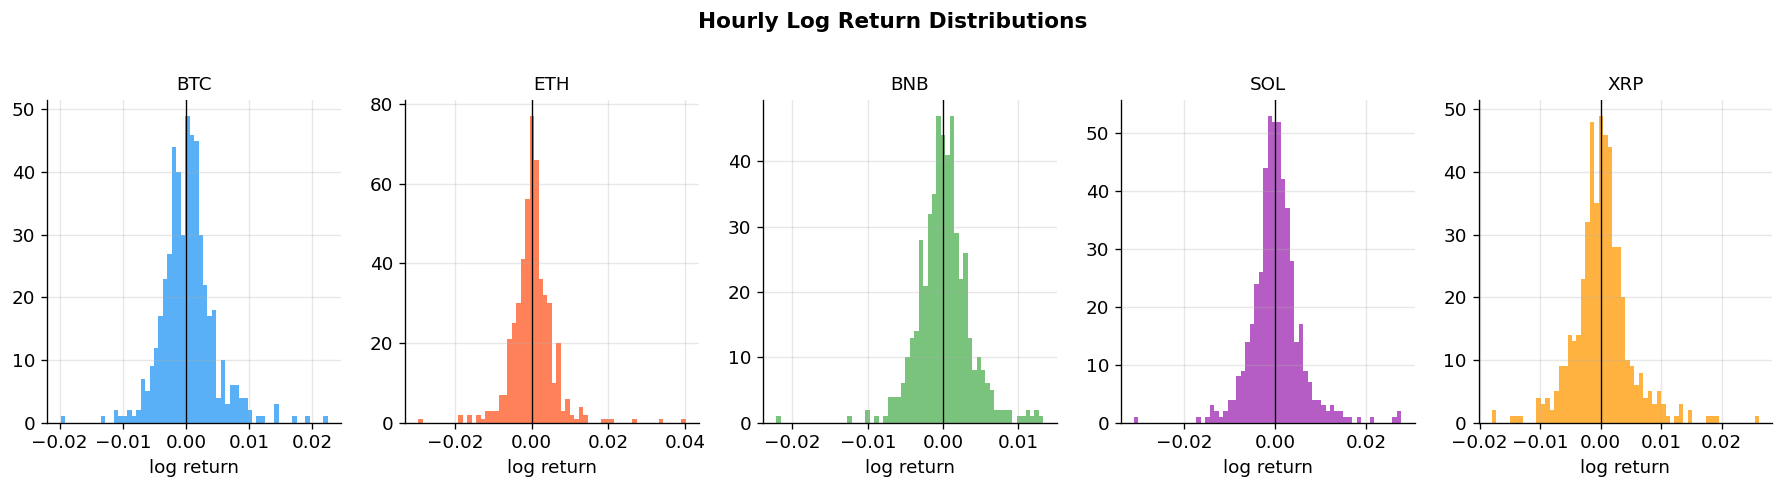


Descriptive Statistics


,mean,std,skew,kurtosis,min,max
symbol,,,,,,
BTCUSDT,0.00031,0.00415,0.62694,4.31644,-0.01985,0.02243
ETHUSDT,0.00028,0.00563,1.05636,10.47521,-0.02960,0.04018
BNBUSDT,0.00014,0.00349,-0.11319,4.56147,-0.02216,0.01331
SOLUSDT,0.00018,0.00544,0.53247,5.97933,-0.03098,0.02772
XRPUSDT,0.00022,0.00468,0.54895,4.09039,-0.01796,0.02619


In [4]:
df_klines['log_return'] = df_klines.groupby('symbol')['close'].transform(
    lambda x: np.log(x / x.shift(1))
)

fig, axes = plt.subplots(1, len(SYMBOLS), figsize=(15, 4), sharey=False)

stats_rows = []
for ax, sym, color in zip(axes, SYMBOLS, COLORS):
    r = df_klines[df_klines['symbol'] == sym]['log_return'].dropna()
    ax.hist(r, bins=60, color=color, alpha=0.75, edgecolor='none')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(sym.replace('USDT', ''), fontsize=11)
    ax.set_xlabel('log return')
    stats_rows.append({
        'symbol': sym, 'mean': r.mean(), 'std': r.std(),
        'skew': r.skew(), 'kurtosis': r.kurtosis(),
        'min': r.min(), 'max': r.max(),
    })

plt.suptitle('Hourly Log Return Distributions', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

df_stats = pd.DataFrame(stats_rows).set_index('symbol').round(5)
print('\nDescriptive Statistics')
df_stats

**Observation:** Excess kurtosis > 0 confirms fat tails in all assets, which motivates using survival analysis (event-based risk) rather than Gaussian VaR.

## 4. Realized Volatility (Rolling 24h)

Annualized realized volatility = `std(log_return, 24h) × √8760`

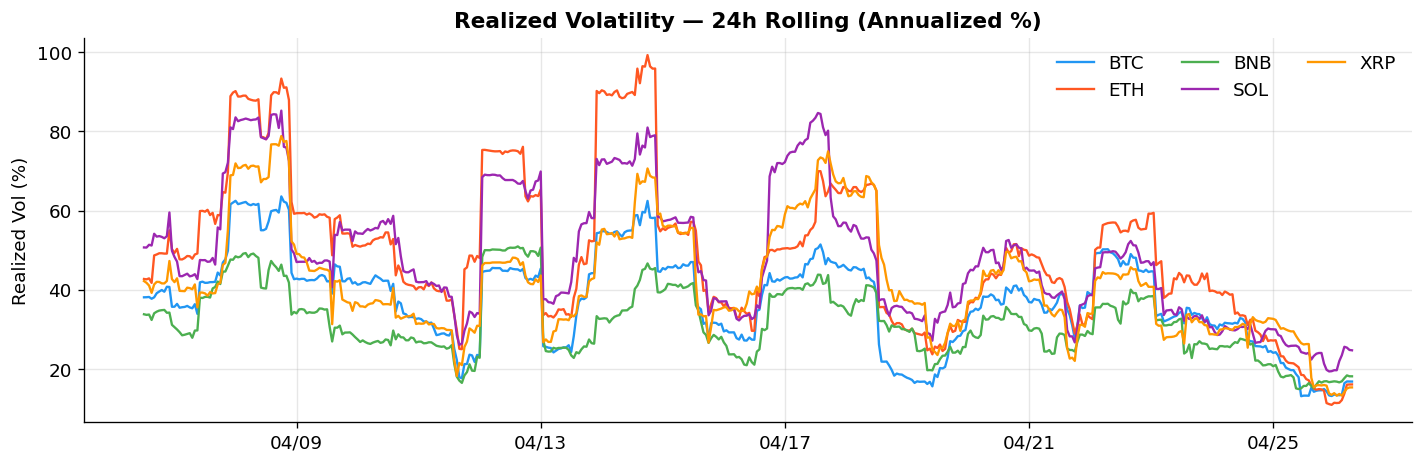

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))

for sym, color in zip(SYMBOLS, COLORS):
    sub = df_klines[df_klines['symbol'] == sym].sort_values('open_time').copy()
    rv = sub['log_return'].rolling(24).std() * np.sqrt(8760) * 100
    ax.plot(sub['open_time'], rv, label=sym.replace('USDT', ''), color=color, linewidth=1.4)

ax.set_title('Realized Volatility — 24h Rolling (Annualized %)', fontsize=13, fontweight='bold')
ax.set_ylabel('Realized Vol (%)')
ax.legend(frameon=False, ncol=3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
plt.tight_layout()
plt.show()

## 5. Volume Profile — Buy vs. Sell Pressure

Binance provides taker buy volume separately. Sell volume = total - taker buy.  
Persistent sell pressure is a leading risk signal.

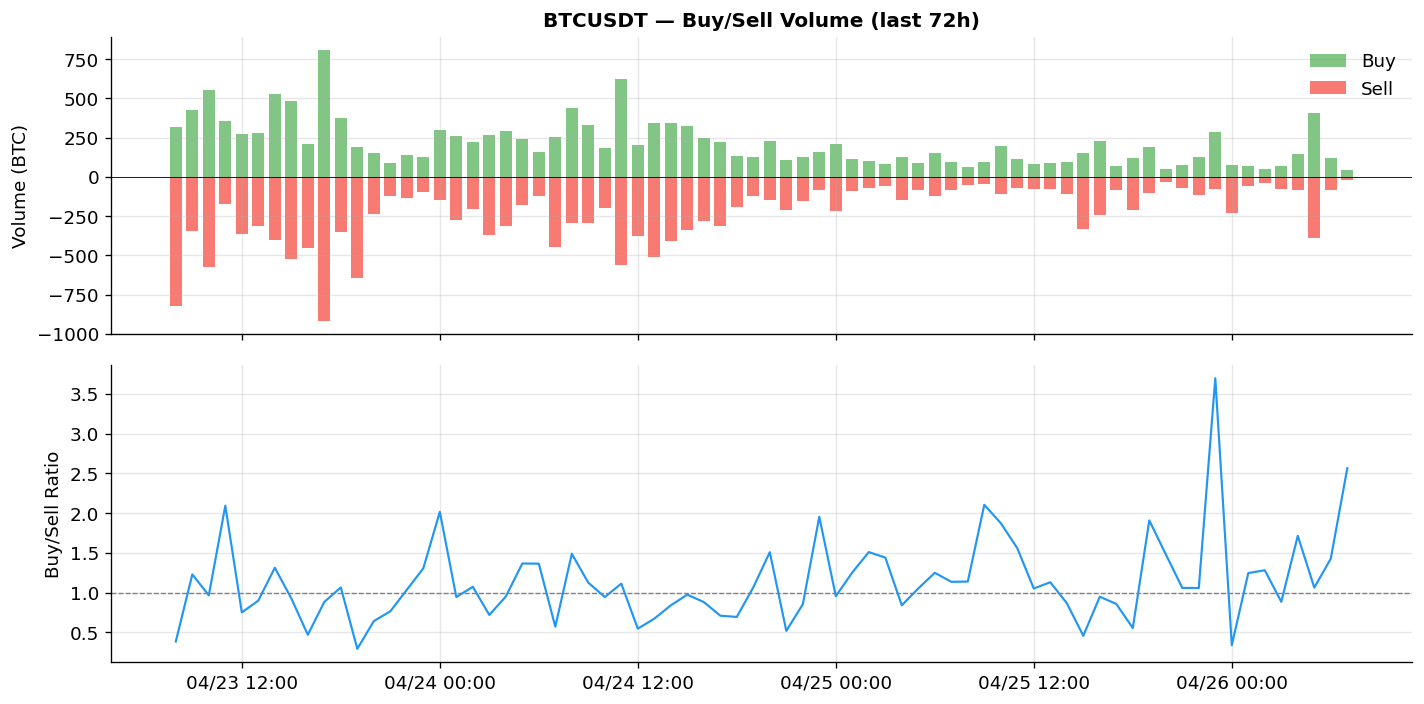

In [6]:
btc = df_klines[df_klines['symbol'] == 'BTCUSDT'].sort_values('open_time').tail(72).copy()
btc['sell_vol'] = btc['volume'] - btc['taker_buy_base_volume']
btc['buy_sell_ratio'] = btc['taker_buy_base_volume'] / btc['sell_vol'].replace(0, np.nan)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax1.bar(btc['open_time'], btc['taker_buy_base_volume'], label='Buy', color='#4CAF50', alpha=0.7, width=0.03)
ax1.bar(btc['open_time'], -btc['sell_vol'], label='Sell', color='#F44336', alpha=0.7, width=0.03)
ax1.axhline(0, color='black', linewidth=0.5)
ax1.set_ylabel('Volume (BTC)')
ax1.set_title('BTCUSDT — Buy/Sell Volume (last 72h)', fontsize=12, fontweight='bold')
ax1.legend(frameon=False)

ax2.plot(btc['open_time'], btc['buy_sell_ratio'], color='#2196F3', linewidth=1.3)
ax2.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
ax2.set_ylabel('Buy/Sell Ratio')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d %H:%M'))

plt.tight_layout()
plt.show()

## 6. Order Book — Spread & Depth Imbalance

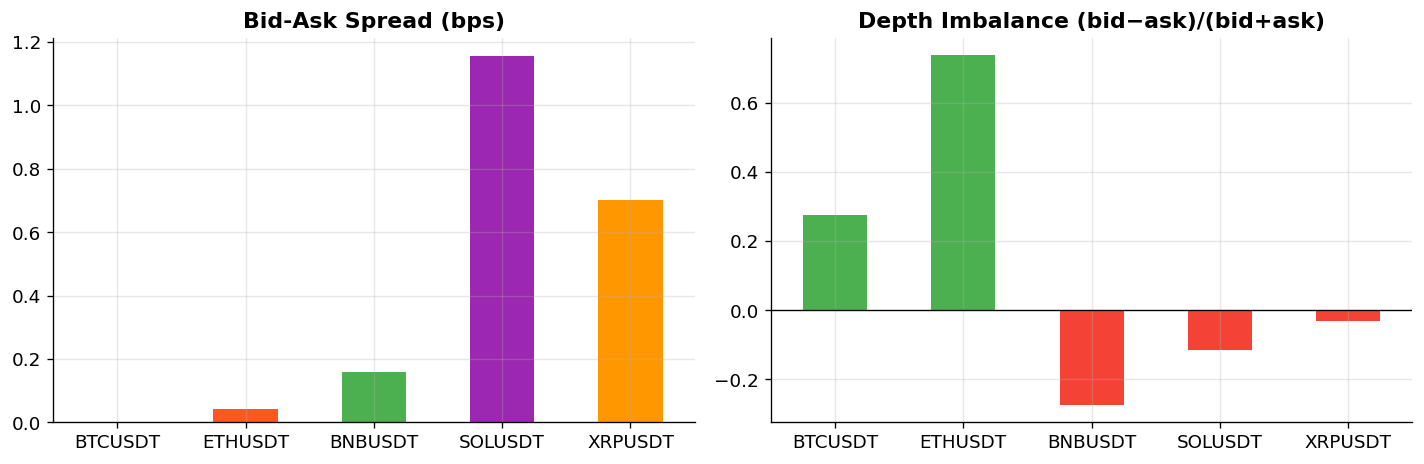


Order Book Snapshot


,spread_bps,mid_price,bid_depth,ask_depth,depth_imbalance
symbol,,,,,
BTCUSDT,0.0013,78011.9950,10.26,5.81,0.2764
ETHUSDT,0.0429,2329.9950,202.82,30.48,0.7387
BNBUSDT,0.1584,631.2650,144.25,253.32,-0.2743
SOLUSDT,1.1559,86.5150,18082.36,22828.44,-0.1160
XRPUSDT,0.7001,1.4284,418907.70,445130.70,-0.0303


In [7]:
book_stats = []
for snap in snapshots:
    book = snap.order_book
    book_stats.append({
        'symbol': snap.symbol,
        'spread_bps': round(book.spread_bps, 4),
        'mid_price': round(book.mid_price, 4),
        'bid_depth': round(book.bid_depth, 2),
        'ask_depth': round(book.ask_depth, 2),
        'depth_imbalance': round(book.depth_imbalance, 4),
    })

df_book = pd.DataFrame(book_stats).set_index('symbol')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

df_book['spread_bps'].plot(kind='bar', ax=ax1, color=COLORS[:len(SYMBOLS)], edgecolor='none')
ax1.set_title('Bid-Ask Spread (bps)', fontweight='bold')
ax1.set_xlabel('')
ax1.tick_params(axis='x', rotation=0)

colors_imb = ['#4CAF50' if v > 0 else '#F44336' for v in df_book['depth_imbalance']]
df_book['depth_imbalance'].plot(kind='bar', ax=ax2, color=colors_imb, edgecolor='none')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('Depth Imbalance (bid−ask)/(bid+ask)', fontweight='bold')
ax2.set_xlabel('')
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print('\nOrder Book Snapshot')
df_book

## 7. Futures Funding Rate

Funding rate is paid every 8 hours between long and short holders.  
- Positive → longs pay shorts (market is over-leveraged long → contraction risk)
- Negative → shorts pay longs (over-leveraged short → squeeze risk)

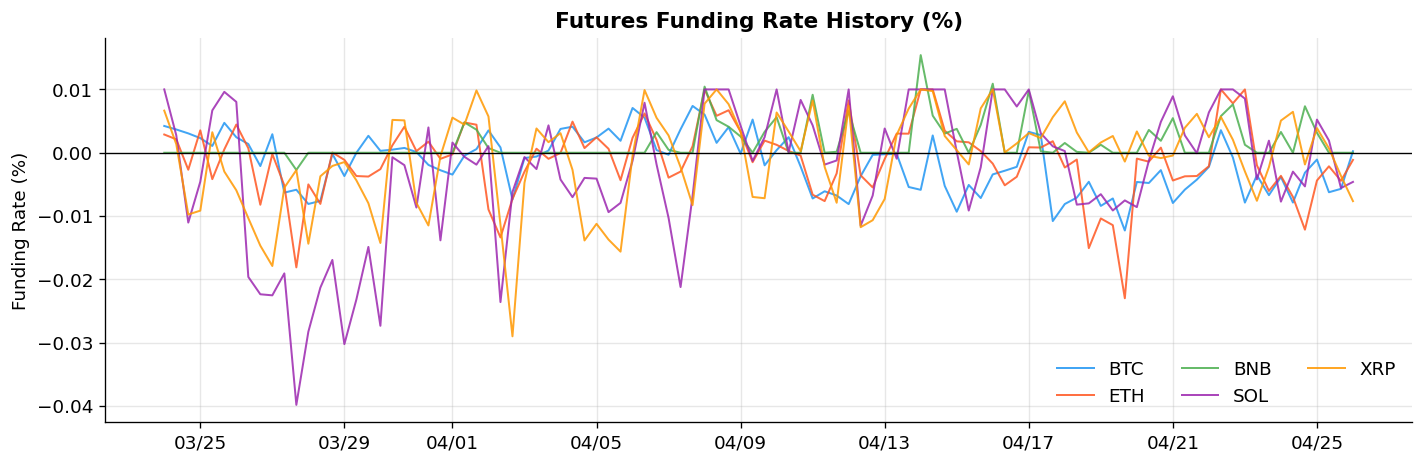

,mean_%,std_%,positive_pct,latest
symbol,,,,
BTCUSDT,-0.00163,0.00442,40.0,0.00024
ETHUSDT,-0.00117,0.00575,45.0,-0.00113
BNBUSDT,0.00153,0.00300,35.0,0.00000
SOLUSDT,-0.00283,0.01071,43.0,-0.00460
XRPUSDT,-0.00100,0.00745,52.0,-0.00764


In [8]:
fig, ax = plt.subplots(figsize=(12, 4))

for snap, color in zip(snapshots, COLORS):
    if not snap.funding_rates:
        continue
    times = [f.funding_time for f in snap.funding_rates]
    rates = [f.funding_rate * 100 for f in snap.funding_rates]  # as %
    ax.plot(times, rates, label=snap.symbol.replace('USDT', ''), color=color, linewidth=1.2, alpha=0.85)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Futures Funding Rate History (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('Funding Rate (%)')
ax.legend(frameon=False, ncol=3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
plt.tight_layout()
plt.show()

fund_stats = []
for snap in snapshots:
    if snap.funding_rates:
        rates = [f.funding_rate for f in snap.funding_rates]
        fund_stats.append({
            'symbol': snap.symbol,
            'mean_%': round(np.mean(rates) * 100, 5),
            'std_%': round(np.std(rates) * 100, 5),
            'positive_pct': round(np.mean([r > 0 for r in rates]) * 100, 1),
            'latest': round(rates[-1] * 100, 5),
        })

pd.DataFrame(fund_stats).set_index('symbol')

## 8. Cross-Asset Return Correlation

High correlation across assets limits diversification and concentrates systemic risk.

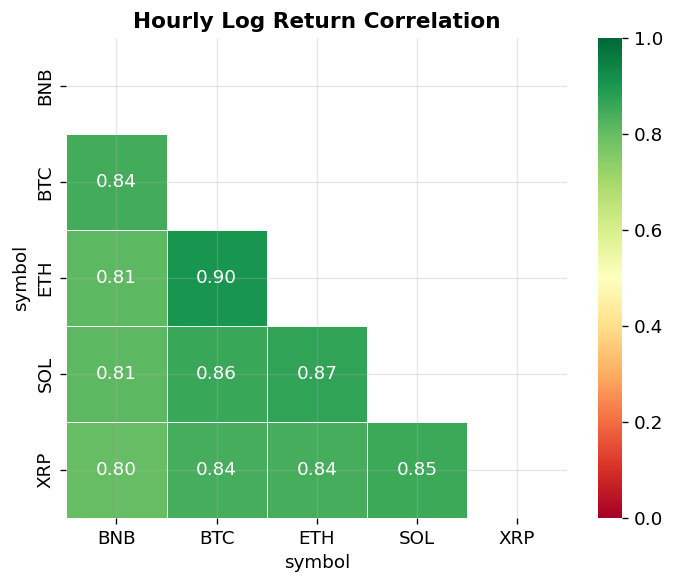

In [9]:
pivot = df_klines.pivot_table(index='open_time', columns='symbol', values='log_return')
corr = pivot.corr()

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=0, vmax=1, ax=ax, linewidths=0.5,
    xticklabels=[s.replace('USDT', '') for s in corr.columns],
    yticklabels=[s.replace('USDT', '') for s in corr.index],
)
ax.set_title('Hourly Log Return Correlation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. 24h Ticker Summary

In [10]:
df_ticker[['symbol', 'last_price', 'price_change_pct', 'volume', 'quote_volume', 'high', 'low', 'count']].round(4)

,symbol,last_price,price_change_pct,volume,quote_volume,high,low,count
0,BTCUSDT,78012.0000,0.688,5.929971e+03,4.602100e+08,78200.0000,77140.230,895533
1,ETHUSDT,2329.9900,0.668,8.898523e+04,2.062134e+08,2336.4800,2300.550,799936
2,BNBUSDT,631.2600,-0.896,6.235576e+04,3.938793e+07,638.5000,627.000,413363
3,SOLUSDT,86.5100,0.209,1.255849e+06,1.082526e+08,86.8000,85.530,335202
4,XRPUSDT,1.4283,-0.265,2.823878e+07,4.025352e+07,1.4371,1.418,172271


## Key Findings

| Observation | Implication for Risk Model |
|---|---|
| Fat-tailed return distributions (kurtosis > 3) | Gaussian VaR underestimates tail risk → survival analysis preferred |
| High cross-asset correlation (>0.5) | Systemic shock propagates across all assets simultaneously |
| Volatile funding rates | Over-leveraged positioning increases liquidation cascade risk |
| Buy/sell ratio fluctuates around 1 | Directional pressure is episodic — regime detection matters |
| Tight bid-ask spreads (< 1 bps for BTC) | Market microstructure friction is minimal for large caps |